In [1]:
print("hii")

hii


In [2]:
# ===========================
#  Basic Library
# ===========================
import os
import cv2
import time
import warnings
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ===========================
#  Feature Extraction
# ===========================

from skimage.feature import hog, local_binary_pattern,graycomatrix, graycoprops

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ===========================
#  Data preprocessing
# ===========================

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedGroupKFold,cross_val_score

# ===========================
#  Evalutaion Metrics
# ===========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ===========================
#  Desplay settings
# ===========================

pd.set_option('display.max_columns', None)
plt.style.use("ggplot")

print("=" * 60)
print("All libraries imported successfully")
print("=" * 60)

All libraries imported successfully


In [3]:
dataset_path = "BrainTumorDataset"
for root, dirs,files, in os.walk(dataset_path):
    print(root)

BrainTumorDataset
BrainTumorDataset\Testing
BrainTumorDataset\Testing\glioma
BrainTumorDataset\Testing\meningioma
BrainTumorDataset\Testing\notumor
BrainTumorDataset\Testing\pituitary
BrainTumorDataset\Training
BrainTumorDataset\Training\glioma
BrainTumorDataset\Training\meningioma
BrainTumorDataset\Training\notumor
BrainTumorDataset\Training\pituitary


In [4]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

classes = sorted(os.listdir(train_path))
print("Classes Found")
print(classes)

print("\nNumber of Classes ", len(classes))

Classes Found
['glioma', 'meningioma', 'notumor', 'pituitary']

Number of Classes  4


In [5]:
train_count = {}
test_count = {}

for cls in classes:
    train_count[cls] = len(os.listdir(os.path.join(train_path, cls)))
    test_count[cls] = len(os.listdir(os.path.join(test_path, cls)))

train_df = pd.DataFrame({
    "Training" : train_count,
    "Testing" : test_count
})

train_df

,Training,Testing
glioma,1400,400
meningioma,1400,400
notumor,1400,400
pituitary,1400,400


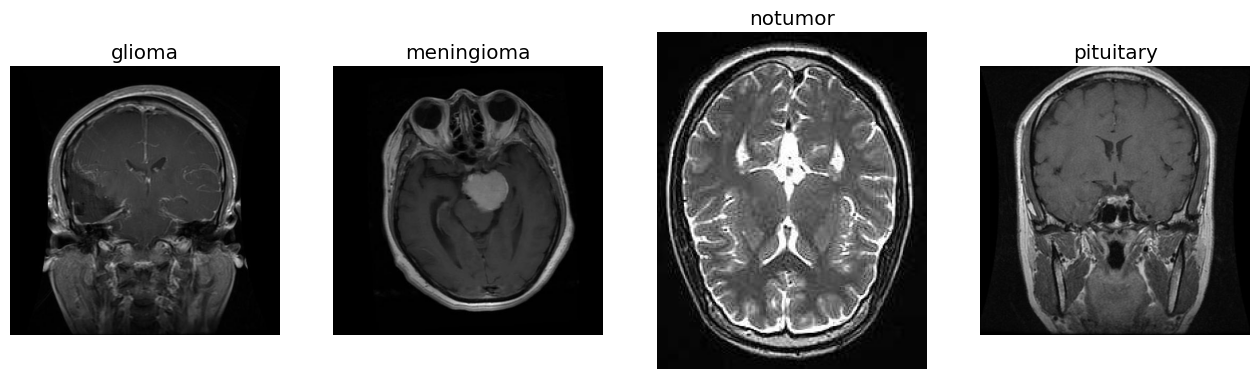

In [6]:
fig, axes = plt.subplots(1, len(classes), figsize=(16,5))

for i, cls in enumerate(classes):
    image_path = os.path.join(
        train_path,
        cls,
        os.listdir(os.path.join(train_path, cls))[0]
    )

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

In [7]:
# image pre processing
# image size

IMG_SIZE = 128

def preprocess_image(image_path):
    """
    Read image, resize, convert to grayscale
    """

    image = cv2.imread(image_path)
    image = cv2.resize(image, (IMG_SIZE , IMG_SIZE))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return gray

In [8]:
# HOG feature

def extract_hog(image):
    features = hog(
        image,
        orientations = 9,
        pixels_per_cell = (8,8),
        cells_per_block = (2,2),
        block_norm = 'L2-Hys',
        feature_vector = True
    )

    return features

In [9]:
# LBP Features

RADIUS = 2
N_POINTS = 8 * RADIUS

def extract_lbp(image):
    lbp = local_binary_pattern(
        image,
        N_POINTS,
        RADIUS,
        method='uniform'
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arrange(0, N_POINTS + 3),
        range=(0,N_POINTS + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)

    return hist

In [15]:
# CLCM Features
def extract_glcm(image):
    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[0],
        levels = 256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast")[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]
    asm = graycoprops(glcm, 'ASM')[0,0]
    return np.array([
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        correlation,
        asm
    ])

In [16]:
# combain all features

def extract_features(image_path):
    image = preprocess_image(image_path)
    hog_features = extract_hog(image)
    lbp_features = extract_lbp(image)
    glcm_features = extract_glcm(image)

    features = np.concatenate([
        hog_features,
        lbp_features,
        glcm_features
    ])

    return features

In [17]:
# Load Dataset
X = []
y = []

for cls in classes:

    folder = os.path.join(train_path, cls)

    print(f"Loading {cls}...")

    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)

        try:
            features = extract_features(image_path)
            X.append(features)
            y.append(cls)
        except:
            continue

Loading glioma...
Loading meningioma...
Loading notumor...
Loading pituitary...


In [13]:
# Load Dataset
X_test = []
y_test = []

for cls in classes:

    folder = os.path.join(test_path, cls)

    print(f"Loading {cls}...")

    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)

        try:
            features = extract_features(image_path)
            X_test.append(features)
            y_test.append(cls)
        except:
            continue

Loading glioma...
Loading meningioma...
Loading notumor...
Loading pituitary...


In [14]:
# conver the above data to numpy aray
X = np.array(X)
X_test = np.array(X_test)

y = np.array(y)
y_test = np.array(y_test)

print("Training Shape: ", X.shape)
print("Testing Shape: ", X_test.shape)

Training Shape:  (0,)
Testing Shape:  (0,)
